https://archive.ics.uci.edu/dataset/10/automobile

# Automobile Dataset - Exploración, limpieza y MLflow

## Fuente de los datos

Para este ejercicio se utiliza el **Automobile Dataset** del 
**UCI Machine Learning Repository**.

**Fuente:**  
UCI Machine Learning Repository – Automobile  
https://archive.ics.uci.edu/dataset/10/automobile

**GitHub:**  
Francisco Gómez Rubio - MNA 710437   
https://github.com/fgomezrubio/Operaciones-ML/blob/main/Tercera-Semana/TC5061_Notebook_Baseline_GomezFrancisco.ipynb

El dataset contiene información relacionada con diferentes características
de automóviles, incluyendo datos técnicos, características del vehículo,
consumo de combustible y precio.

El objetivo del ejercicio es realizar un proceso completo que incluya:

- Carga y exploración de los datos.
- Identificación y tratamiento de valores nulos.
- Identificación de registros duplicados.
- Revisión y transformación de tipos de datos.
- Análisis de posibles valores atípicos.
- Transformación de variables categóricas.
- Análisis exploratorio mediante estadísticas y visualizaciones.
- Entrenamiento y evaluación de un modelo base de regresión.
- Registro de parámetros y métricas mediante MLflow.

La variable **`price`** se utiliza como variable objetivo para construir
un modelo que permita estimar el precio de un automóvil a partir de sus
características.

## 1. Carga y configuración
Colocar `imports-85.data` junto al notebook. Si no está disponible, se puede cargar directamente desde UCI con `ucimlrepo` (requiere internet).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

RUTA = Path('automobile/imports-85.data')
FACTOR_IQR = 1.5
COLUMNA_GRAFICA = 'price'
COLUMNAS = ['symboling','normalized-losses','make','fuel-type','aspiration',
            'num-of-doors','body-style','drive-wheels','engine-location',
            'wheel-base','length','width','height','curb-weight','engine-type',
            'num-of-cylinders','engine-size','fuel-system','bore','stroke',
            'compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price']

if RUTA.exists():
    df_original = pd.read_csv(RUTA, header=None, names=COLUMNAS, na_values=['?'])
else:
    try:
        from ucimlrepo import fetch_ucirepo
    except ImportError as exc:
        raise FileNotFoundError('Coloca imports-85.data junto al notebook o instala ucimlrepo') from exc
    uci = fetch_ucirepo(id=10)
    df_original = pd.concat([uci.data.features, uci.data.targets], axis=1)
    df_original = df_original.loc[:, ~df_original.columns.duplicated()]
    df_original = df_original[COLUMNAS]
df = df_original.copy()
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
display(df.head())

Dimensiones: 205 filas × 26 columnas


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,2.0,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,4.0,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,4.0,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### Interpretación de la carga

El archivo se carga en un `DataFrame`, que organiza la información en filas y columnas.

Cada fila representa un automóvil y cada columna describe alguna de sus características. En esta etapa también se identifican los valores faltantes para que puedan revisarse durante la limpieza.


## 2. Exploración: variable objetivo y variables descriptivas
Aquí `price` se toma como objetivo para un posible ejercicio de regresión. `symboling` es una calificación discreta de riesgo; aunque Pandas la lea como entero, la revisaremos como variable discreta, no como una medida continua para IQR.

In [2]:
y = df['price']
X = df.drop(columns=['price'])
# Se trata symboling como discreta/categórica para la exploración.
DISCRETAS = ['symboling']
X_numericas = X.select_dtypes(include='number').drop(columns=DISCRETAS, errors='ignore')
X_categoricas = X.select_dtypes(include=['object','string','category']).copy()
X_categoricas = pd.concat([X_categoricas, X[DISCRETAS]], axis=1)
print('Numéricas descriptivas:', X_numericas.columns.tolist())
print('Categóricas y discretas:', X_categoricas.columns.tolist())
print('Objetivo:', y.name)
display(X_numericas.describe().T)
display(X_categoricas.astype('string').describe().T)
display(y.describe().to_frame('price'))

Numéricas descriptivas: ['normalized-losses', 'num-of-doors', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'num-of-cylinders', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg']
Categóricas y discretas: ['make', 'fuel-type', 'aspiration', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'fuel-system', 'symboling']
Objetivo: price


,count,mean,std,min,25%,50%,75%,max
normalized-losses,164.0,122.000000,35.442168,65.00,94.00,115.00,150.00,256.00
num-of-doors,203.0,3.123153,0.994841,2.00,2.00,4.00,4.00,4.00
wheel-base,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
length,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
width,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
height,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curb-weight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
num-of-cylinders,205.0,4.380488,1.080854,2.00,4.00,4.00,4.00,12.00
engine-size,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
bore,201.0,3.329751,0.273539,2.54,3.15,3.31,3.59,3.94


,count,unique,top,freq
make,205,22,toyota,32
fuel-type,205,2,gas,185
aspiration,205,2,std,168
body-style,205,5,sedan,96
drive-wheels,205,3,fwd,120
engine-location,205,2,front,202
engine-type,205,7,ohc,148
fuel-system,205,8,mpfi,94
symboling,205,6,0,67


,price
count,201.000000
mean,13207.129353
std,7947.066342
min,5118.000000
25%,7775.000000
50%,10295.000000
75%,16500.000000
max,45400.000000


### Interpretación de las variables

La variable `price` se utiliza como **variable objetivo**, porque representa el valor que posteriormente se desea predecir.

El resto de las columnas se consideran **variables descriptivas**. Estas contienen las características del automóvil que el modelo utilizará para intentar estimar su precio.


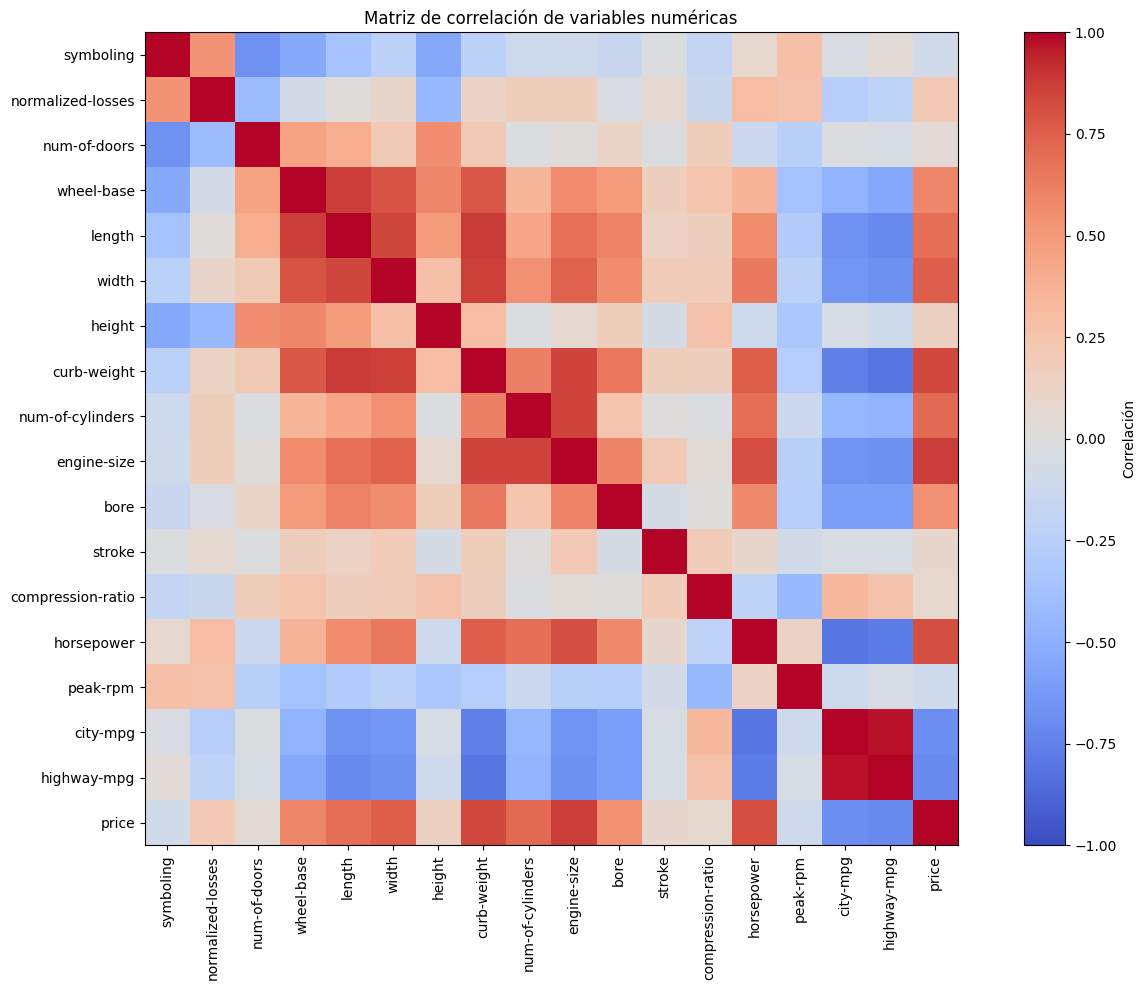

In [27]:
import matplotlib.pyplot as plt

correlacion = df.select_dtypes(include="number").corr()

plt.figure(figsize=(14, 10))

plt.imshow(
    correlacion,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlación")

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

In [28]:
correlacion_precio = (
    correlacion["price"]
    .drop("price")
    .sort_values(ascending=False)
)

display(
    correlacion_precio.to_frame(
        "Correlación con price"
    )
)

,Correlación con price
engine-size,0.872335
curb-weight,0.834415
horsepower,0.810533
width,0.751265
num-of-cylinders,0.708645
length,0.690628
wheel-base,0.584642
bore,0.543436
normalized-losses,0.203254
height,0.135486


### Interpretación de correlaciones

La matriz de correlación permite identificar relaciones lineales entre las variables numéricas del dataset.

Para este ejercicio resulta especialmente importante analizar la relación de las variables con `price`, ya que esta es la variable que posteriormente se desea predecir.

Los valores cercanos a **1** indican una relación positiva fuerte, los cercanos a **-1** una relación negativa fuerte y los cercanos a **0** indican poca relación lineal.

Una correlación alta no implica que una variable sea la causa del precio; únicamente indica que ambas presentan una asociación lineal en los datos.

## 3. Nulos y duplicados
Los signos `?` ya se interpretaron como nulos. Revisar tanto el número como el porcentaje. No confundir filas idénticas con vehículos de características iguales y distinto precio.

In [3]:
resumen_nulos = pd.DataFrame({'nulos':df.isna().sum(), 'porcentaje':(100*df.isna().mean()).round(2)})
display(resumen_nulos[resumen_nulos.nulos > 0].sort_values('nulos',ascending=False))
print('Duplicados exactos adicionales:', df.duplicated().sum())
display(df.loc[df.duplicated(keep=False)].head(20))

,nulos,porcentaje
normalized-losses,41,20.00
bore,4,1.95
stroke,4,1.95
price,4,1.95
num-of-doors,2,0.98
horsepower,2,0.98
peak-rpm,2,0.98


Duplicados exactos adicionales: 0


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price


### Interpretación de nulos y duplicados

Esta revisión permite conocer qué columnas tienen información faltante y qué porcentaje representan esos datos.

También se buscan registros duplicados. Un valor nulo o un registro repetido no debe eliminarse automáticamente: primero debe analizarse si realmente representa un problema para el objetivo del ejercicio.


## 4. Diagnóstico de tipos y conversión de cantidades
`num-of-cylinders` y `num-of-doors` son cantidades escritas con palabras. **Primero** comprobar valores desconocidos; **después** convertirlos. No aplicar One-Hot a estas cantidades por defecto. Las categorías nominales se mantienen como texto.

### Actualizar la separación después de las conversiones
Después de convertir `num-of-cylinders` y `num-of-doors`, ambas pasan a ser variables numéricas discretas. Por ello se vuelven a construir `X`, `X_numericas` y `X_categoricas`. Los DataFrames creados antes no se actualizan automáticamente cuando cambia `df`.

In [4]:
# ============================================================
# PUNTO 4. CONVERSIÓN DE CANTIDADES A VALORES NUMÉRICOS
# ============================================================

MAPAS = {
    "num-of-cylinders": {
        "two": 2, "three": 3, "four": 4, "five": 5,
        "six": 6, "eight": 8, "twelve": 12
    },
    "num-of-doors": {
        "two": 2, "four": 4
    }
}

for col, mapa in MAPAS.items():

    print(f"\n--- {col} ---")
    print("Valores antes de la conversión:")
    display(df[col].value_counts(dropna=False).to_frame("frecuencia"))

    # Se trabaja con texto normalizado para aceptar tanto:
    # "four" -> 4, como valores que ya vengan como 4 o 4.0.
    texto = (
        df[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    # Primera opción: convertir palabras conocidas.
    desde_texto = texto.map(mapa)

    # Segunda opción: conservar valores que ya sean numéricos.
    desde_numero = pd.to_numeric(texto, errors="coerce")

    # Se usa la conversión por palabra cuando existe;
    # en caso contrario se intenta conservar el valor numérico.
    convertido = desde_texto.fillna(desde_numero)

    # Detectar únicamente valores originales no nulos
    # que no pudieron convertirse de ninguna forma.
    desconocidos = texto.notna() & convertido.isna()

    print("Valores no reconocidos:", int(desconocidos.sum()))

    if desconocidos.any():
        print("⚠ Se encontraron valores que deben revisarse:")
        display(
            df.loc[desconocidos, [col]]
            .value_counts(dropna=False)
            .to_frame("frecuencia")
        )
    else:
        print("✓ Todos los valores no nulos fueron reconocidos.")

    df[col] = convertido.astype("Int64")

print("\nTipos después de la conversión:")
print(df[["num-of-cylinders", "num-of-doors"]].dtypes)

print("\nValores después de la conversión:")
for col in MAPAS:
    print(f"\n{col}")
    display(
        df[col]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame("frecuencia")
    )

# Actualizar la separación de variables después de convertir.
y = df["price"]
X = df.drop(columns=["price"])

DISCRETAS_NUMERICAS = [
    "symboling",
    "num-of-cylinders",
    "num-of-doors"
]

X_numericas = X.select_dtypes(include="number").copy()
X_categoricas = X.select_dtypes(
    include=["object", "string", "category"]
).copy()

print("\nVariables numéricas después de la conversión:")
print(X_numericas.columns.tolist())

print("\nVariables categóricas después de la conversión:")
print(X_categoricas.columns.tolist())

print("\nVariables numéricas discretas:")
print(DISCRETAS_NUMERICAS)



--- num-of-cylinders ---
Valores antes de la conversión:


,frecuencia
num-of-cylinders,
4,159
6,24
5,11
8,5
2,4
12,1
3,1


Valores no reconocidos: 0
✓ Todos los valores no nulos fueron reconocidos.

--- num-of-doors ---
Valores antes de la conversión:


,frecuencia
num-of-doors,
4.0,114
2.0,89
NaN,2


Valores no reconocidos: 0
✓ Todos los valores no nulos fueron reconocidos.

Tipos después de la conversión:
num-of-cylinders    Int64
num-of-doors        Int64
dtype: object

Valores después de la conversión:

num-of-cylinders


,frecuencia
num-of-cylinders,
2,4
3,1
4,159
5,11
6,24
8,5
12,1



num-of-doors


,frecuencia
num-of-doors,
2,89
4,114
<NA>,2



Variables numéricas después de la conversión:
['symboling', 'normalized-losses', 'num-of-doors', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'num-of-cylinders', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg']

Variables categóricas después de la conversión:
['make', 'fuel-type', 'aspiration', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'fuel-system']

Variables numéricas discretas:
['symboling', 'num-of-cylinders', 'num-of-doors']


### Interpretación de la conversión

`num-of-cylinders` y `num-of-doors` representan cantidades, aunque originalmente puedan aparecer como texto.

La intención de esta transformación es convertir esas cantidades a valores numéricos para que puedan utilizarse correctamente durante el análisis y el entrenamiento.

**Importante:** antes de continuar se debe comprobar que los valores obtenidos sean correctos y que la conversión no haya generado valores nulos inesperados.


### Exploración visual de cilindros y puertas por marca

Después de convertir ambas variables a valores numéricos, se puede analizar cómo se distribuyen el número de cilindros y el número de puertas entre las diferentes marcas.

Estas visualizaciones complementan las estadísticas descriptivas y permiten identificar diferencias en la composición de los vehículos de cada fabricante.


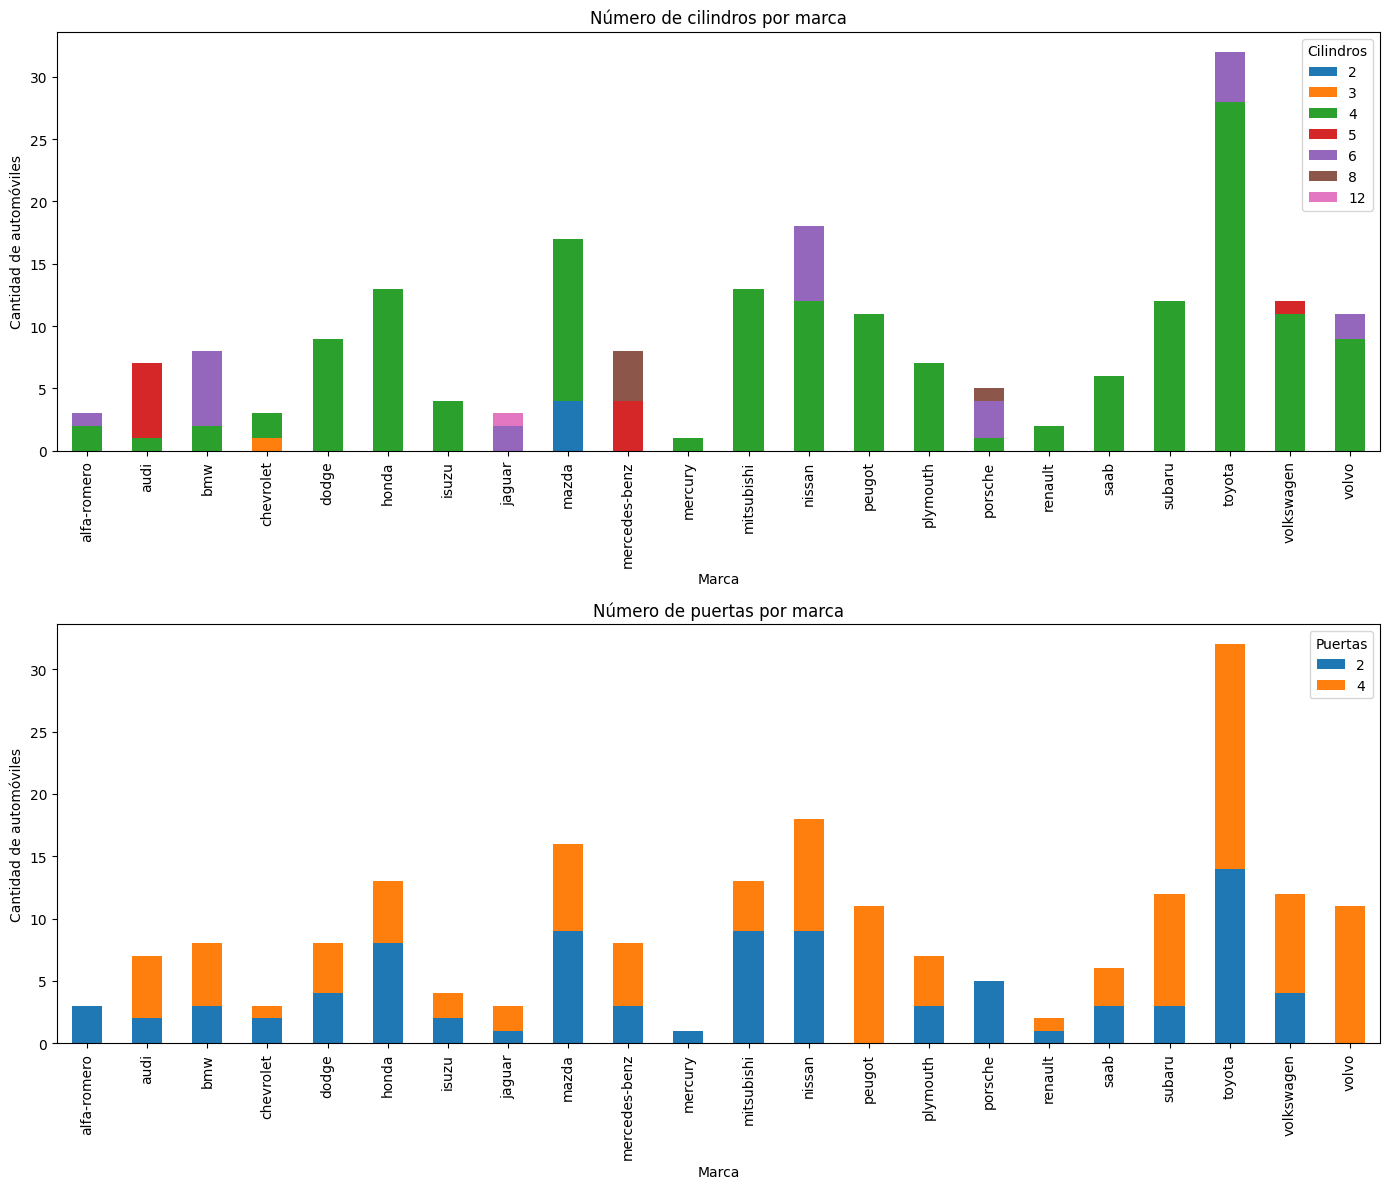

In [5]:
tabla_cilindros = pd.crosstab(
    df["make"],
    df["num-of-cylinders"]
)

tabla_puertas = pd.crosstab(
    df["make"],
    df["num-of-doors"]
)

fig, ax = plt.subplots(2, 1, figsize=(14, 12))

tabla_cilindros.plot(
    kind="bar",
    stacked=True,
    ax=ax[0]
)
ax[0].set_title("Número de cilindros por marca")
ax[0].set_xlabel("Marca")
ax[0].set_ylabel("Cantidad de automóviles")
ax[0].legend(title="Cilindros")
ax[0].tick_params(axis="x", rotation=90)

tabla_puertas.plot(
    kind="bar",
    stacked=True,
    ax=ax[1]
)
ax[1].set_title("Número de puertas por marca")
ax[1].set_xlabel("Marca")
ax[1].set_ylabel("Cantidad de automóviles")
ax[1].legend(title="Puertas")
ax[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


### Interpretación

Las gráficas muestran que las marcas no tienen necesariamente la misma composición de vehículos.

La distribución de cilindros permite observar qué configuraciones de motor son más frecuentes en cada marca, mientras que la distribución de puertas permite comparar la presencia de vehículos de dos y cuatro puertas.

Estas diferencias ayudan a comprender mejor las características del dataset antes de construir el modelo.


## 5. Validación de variables categóricas
Después de la conversión, `num-of-cylinders` y `num-of-doors` ya no pertenecen a este grupo. Para las variables categóricas nominales se aplican tres diagnósticos: **catálogo de valores permitidos**, **variantes de escritura** y **categorías poco frecuentes**. Una categoría rara no es automáticamente incorrecta.

In [6]:
CATALOGOS = {
 'fuel-type': {'gas','diesel'}, 'aspiration': {'std','turbo'},
 'body-style': {'hardtop','wagon','sedan','hatchback','convertible'},
 'drive-wheels': {'4wd','fwd','rwd'}, 'engine-location': {'front','rear'},
 'engine-type': {'dohc','dohcv','l','ohc','ohcf','ohcv','rotor'},
 'fuel-system': {'1bbl','2bbl','4bbl','idi','mfi','mpfi','spdi','spfi'},
 'make': {'alfa-romero','audi','bmw','chevrolet','dodge','honda','isuzu','jaguar',
          'mazda','mercedes-benz','mercury','mitsubishi','nissan','peugot',
          'plymouth','porsche','renault','saab','subaru','toyota','volkswagen','volvo'}
}
incidencias_cat = []
for col in X_categoricas.columns:
    s = df[col].astype('string')
    normalizada = s.str.strip().str.lower()
    if col in CATALOGOS:
        invalida = s.notna() & ~normalizada.isin(CATALOGOS[col])
        for indice in df.index[invalida]:
            incidencias_cat.append({'fila':indice,'columna':col,'valor':s.loc[indice], 'motivo':'Fuera del catálogo'})
    variantes = pd.DataFrame({'original':s,'normalizada':normalizada}).dropna().drop_duplicates()
    variantes = variantes.groupby('normalizada')['original'].agg(list)
    variantes = variantes[variantes.map(len)>1]
    if not variantes.empty:
        print(f'Variantes de escritura en {col}:'); display(variantes.to_frame('variantes'))
    poco_frecuentes = s.value_counts(dropna=True)
    poco_frecuentes = poco_frecuentes[poco_frecuentes <= 2]
    if not poco_frecuentes.empty:
        print(f'Categorías con frecuencia ≤ 2 en {col} (solo revisión):')
        display(poco_frecuentes.to_frame('frecuencia'))

reporte_categorias = pd.DataFrame(incidencias_cat,columns=['fila','columna','valor','motivo'])
print('Incidencias fuera de catálogo:',len(reporte_categorias))
display(reporte_categorias.head(30))

Categorías con frecuencia ≤ 2 en make (solo revisión):


,frecuencia
make,
renault,2
mercury,1


Categorías con frecuencia ≤ 2 en engine-type (solo revisión):


,frecuencia
engine-type,
dohcv,1


Categorías con frecuencia ≤ 2 en fuel-system (solo revisión):


,frecuencia
fuel-system,
mfi,1
spfi,1


Incidencias fuera de catálogo: 0


,fila,columna,valor,motivo


### Interpretación de las categorías

Se revisan los valores de las variables categóricas para detectar categorías inesperadas, errores de escritura o valores que no correspondan al catálogo esperado.

Una categoría que aparece pocas veces no necesariamente es incorrecta. Puede representar simplemente un caso poco frecuente dentro del conjunto de datos.


### Nota sobre catálogos y errores documentados
El catálogo de UCI contiene literalmente `alfa-romero` y `peugot`. La pertenencia al catálogo **no garantiza ortografía comercial correcta**. Corregir nombres de fabricantes requiere una fuente de referencia externa y una decisión documentada; no sustituirlos automáticamente durante el diagnóstico.

## 6. Outliers numéricos con IQR
El método IQR se aplica a variables numéricas **continuas** y, por separado, a `price`. No se aplica a `symboling`, `num-of-cylinders` ni `num-of-doors`, porque son variables discretas: para ellas es más útil comprobar valores permitidos o reglas de dominio. `FACTOR_IQR = 1.5` detecta candidatos habituales; aumentar el factor reduce la sensibilidad.

In [7]:
CONTINUAS = [c for c in X_numericas.columns if c not in DISCRETAS_NUMERICAS]
COLUMNAS_IQR = CONTINUAS + ['price']
resumen_iqr = []
filas_iqr = []
for col in COLUMNAS_IQR:
    s = pd.to_numeric(df[col],errors='coerce').replace([np.inf,-np.inf],np.nan)
    if s.notna().sum()<4: continue
    q1,q3=s.quantile([.25,.75]); rango=q3-q1
    if rango==0: continue
    inferior,superior=q1-FACTOR_IQR*rango,q3+FACTOR_IQR*rango
    mascara=s.notna() & ((s<inferior)|(s>superior))
    resumen_iqr.append({'columna':col,'Q1':q1,'Q3':q3,'IQR':rango,
                        'limite_inferior':inferior,'limite_superior':superior,
                        'atipicos':int(mascara.sum())})
    for idx in df.index[mascara]:
        filas_iqr.append({'fila':idx,'columna':col,'valor':s.loc[idx],
                          'limite_inferior':inferior,'limite_superior':superior,
                          'motivo':'Fuera de límites IQR'})
reporte_iqr=pd.DataFrame(resumen_iqr)
detalle_iqr=pd.DataFrame(filas_iqr)
display(reporte_iqr.sort_values('atipicos',ascending=False))
display(detalle_iqr.head(20))

,columna,Q1,Q3,IQR,limite_inferior,limite_superior,atipicos
9,compression-ratio,8.60,9.40,0.80,7.40,10.60,28
8,stroke,3.11,3.41,0.30,2.66,3.86,20
14,price,7775.00,16500.00,8725.00,-5312.50,29587.50,14
6,engine-size,97.00,141.00,44.00,31.00,207.00,10
3,width,64.10,66.90,2.80,59.90,71.10,8
10,horsepower,70.00,116.00,46.00,1.00,185.00,6
1,wheel-base,94.50,102.40,7.90,82.65,114.25,3
13,highway-mpg,25.00,34.00,9.00,11.50,47.50,3
12,city-mpg,19.00,30.00,11.00,2.50,46.50,2
11,peak-rpm,4800.00,5500.00,700.00,3750.00,6550.00,2


,fila,columna,valor,limite_inferior,limite_superior,motivo
0,190,normalized-losses,256.0,10.00,234.00,Fuera de límites IQR
1,70,wheel-base,115.6,82.65,114.25,Fuera de límites IQR
2,71,wheel-base,115.6,82.65,114.25,Fuera de límites IQR
3,73,wheel-base,120.9,82.65,114.25,Fuera de límites IQR
4,18,length,141.1,141.10,208.30,Fuera de límites IQR
5,6,width,71.4,59.90,71.10,Fuera de límites IQR
6,7,width,71.4,59.90,71.10,Fuera de límites IQR
7,8,width,71.4,59.90,71.10,Fuera de límites IQR
8,70,width,71.7,59.90,71.10,Fuera de límites IQR
9,71,width,71.7,59.90,71.10,Fuera de límites IQR


### Interpretación de los outliers

El método IQR identifica valores numéricos que se encuentran alejados de la mayoría de las observaciones.

Estos valores se consideran **candidatos a revisión**, no errores automáticos. Por ejemplo, un automóvil muy costoso puede ser poco común y, al mismo tiempo, ser un dato completamente válido.


### Gráficas de una variable
Cambiar `COLUMNA_GRAFICA` en la configuración para inspeccionar cada distribución.

<Figure size 1400x600 with 0 Axes>

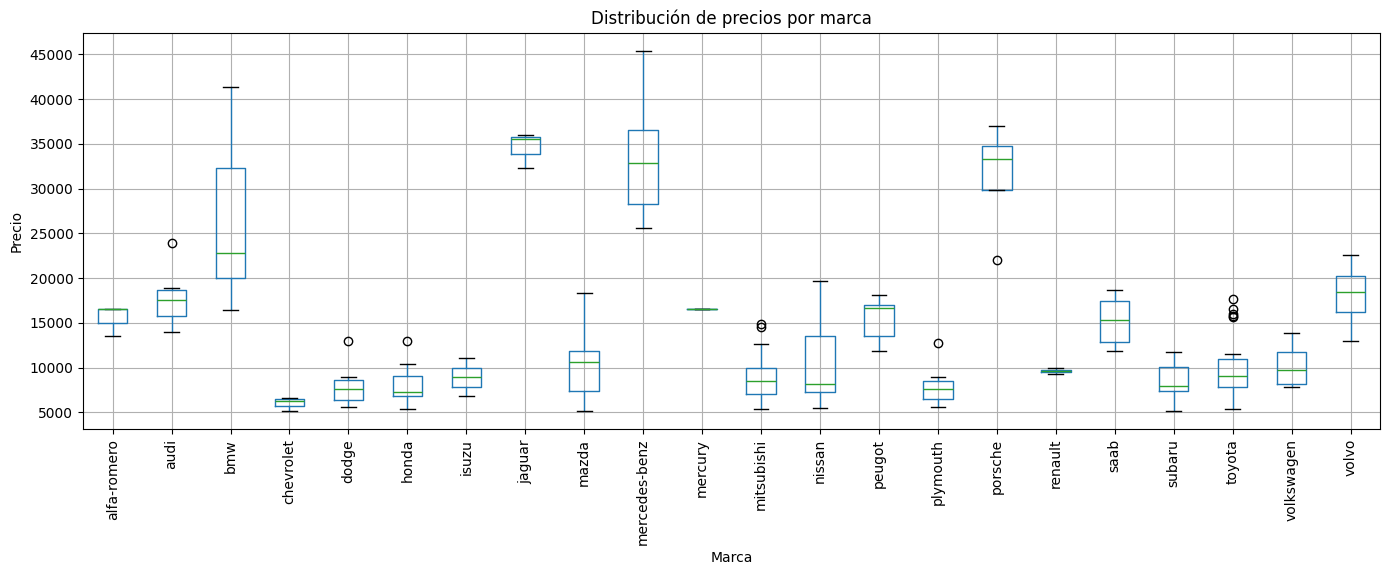

In [8]:
plt.figure(figsize=(14, 6))

df.boxplot(
    column="price",
    by="make",
    figsize=(14, 6),
    rot=90
)

plt.title("Distribución de precios por marca")
plt.suptitle("")
plt.xlabel("Marca")
plt.ylabel("Precio")

plt.tight_layout()
plt.show()

### Interpretación

El boxplot permite comparar la distribución de precios entre las diferentes marcas.

Se observan diferencias tanto en el nivel de precios como en su dispersión. Algunas marcas presentan precios relativamente concentrados, mientras que otras muestran una mayor variabilidad.

También aparecen algunos valores alejados de la distribución principal de su propia marca. Estos pueden considerarse posibles valores atípicos, pero no necesariamente representan errores. Pueden corresponder a modelos con características diferentes dentro de la misma marca.

### Interpretación del histograma y boxplot

El histograma permite observar cómo se distribuyen los precios, mientras que el boxplot facilita la identificación visual de precios alejados del comportamiento general.

Los puntos alejados se consideran candidatos a revisión y no deben eliminarse automáticamente, ya que un precio elevado puede ser válido para determinados vehículos.


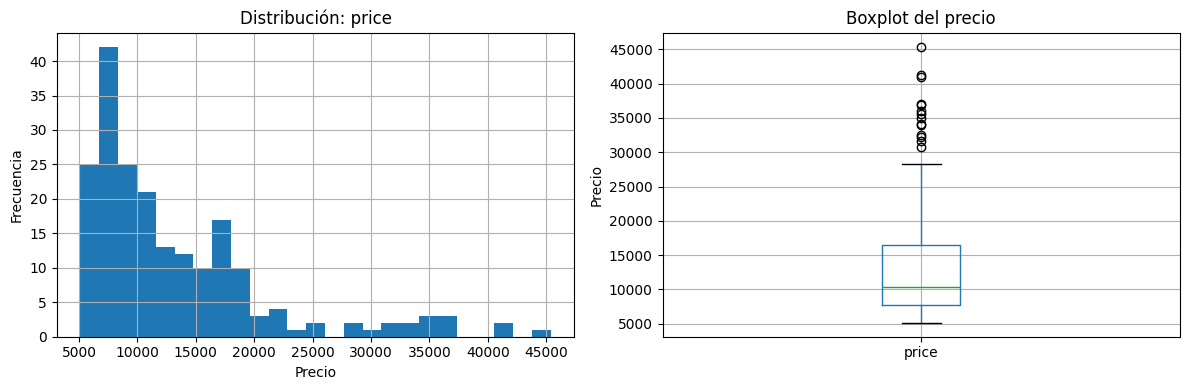

In [9]:
COLUMNA_GRAFICA = "price"

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
df[COLUMNA_GRAFICA].dropna().hist(
    bins=25,
    ax=ax[0]
)

ax[0].set_title(f"Distribución: {COLUMNA_GRAFICA}")
ax[0].set_xlabel("Precio")
ax[0].set_ylabel("Frecuencia")

# Boxplot
df.boxplot(
    column=COLUMNA_GRAFICA,
    ax=ax[1]
)

ax[1].set_title("Boxplot del precio")
ax[1].set_ylabel("Precio")

plt.tight_layout()
plt.show()

## 7. Reglas de dominio y límites
Aquí se separan dos ideas: **valores permitidos para variables discretas** y **límites numéricos de negocio**. Para las variables discretas no se usa IQR. Los rangos históricos documentados del dataset sirven como referencia diagnóstica, no como límites físicos universales.

In [10]:
# Valores permitidos para variables numéricas discretas
VALORES_DISCRETOS_VALIDOS = {
    "symboling": {-2, -1, 0, 1, 2, 3},
    "num-of-cylinders": {2, 3, 4, 5, 6, 8, 12},
    "num-of-doors": {2, 4}
}

reporte_discretas = []
for col, permitidos in VALORES_DISCRETOS_VALIDOS.items():
    mascara = df[col].notna() & ~df[col].isin(permitidos)
    print(f"{col}: {int(mascara.sum())} valores fuera del conjunto permitido")
    for idx in df.index[mascara]:
        reporte_discretas.append({
            "fila": idx, "columna": col, "valor": df.loc[idx, col],
            "motivo": "Valor discreto no permitido"
        })

reporte_discretas = pd.DataFrame(reporte_discretas,
                                  columns=["fila","columna","valor","motivo"])
if not reporte_discretas.empty:
    display(reporte_discretas)

# Mínimos ilustrativos; None significa que no se impone ese límite.
# El cero en precio se señala para revisión, sin eliminar automáticamente.
RANGOS_NEGOCIO = {'price':(0,None),'horsepower':(0,None),
                  'engine-size':(0,None),'city-mpg':(0,None),
                  'highway-mpg':(0,None),'num-of-cylinders':(1,None),
                  'num-of-doors':(1,None)}
# Límites observados documentados por UCI: diagnóstico histórico, NO reglas universales.
RANGOS_UCI = {'price':(5118,45400),'horsepower':(48,288),
              'peak-rpm':(4150,6600),'engine-size':(61,326)}

def evaluar_rangos(data, rangos, motivo):
    resultados=[]
    for col,(lo,hi) in rangos.items():
        if col not in data: continue
        s=pd.to_numeric(data[col],errors='coerce')
        mask=pd.Series(False,index=data.index)
        if lo is not None: mask |= s<lo
        if hi is not None: mask |= s>hi
        for idx in data.index[mask.fillna(False)]:
            resultados.append({'fila':idx,'columna':col,'valor':data.at[idx,col],
                               'minimo':lo,'maximo':hi,'motivo':motivo})
    return pd.DataFrame(resultados,columns=['fila','columna','valor','minimo','maximo','motivo'])
reporte_negocio=evaluar_rangos(df,RANGOS_NEGOCIO,'Revisar regla de negocio')
reporte_historico=evaluar_rangos(df,RANGOS_UCI,'Fuera de rango histórico UCI')
print('Incidencias de negocio:',len(reporte_negocio))
display(reporte_negocio)
print('Fuera de rangos históricos:',len(reporte_historico))
display(reporte_historico)

symboling: 0 valores fuera del conjunto permitido
num-of-cylinders: 0 valores fuera del conjunto permitido
num-of-doors: 0 valores fuera del conjunto permitido
Incidencias de negocio: 0


,fila,columna,valor,minimo,maximo,motivo


Fuera de rangos históricos: 0


,fila,columna,valor,minimo,maximo,motivo


### Interpretación de las reglas de dominio

Las reglas de dominio permiten revisar los datos utilizando conocimiento del problema, no solamente criterios estadísticos.

Un valor puede ser estadísticamente poco común y seguir siendo válido. En cambio, un valor fuera de los valores permitidos puede indicar un problema de calidad que debe revisarse.


## 8. Reporte consolidado y decisiones
Cada incidencia debe tener una decisión documentada: **conservar, corregir, imputar, eliminar o investigar**. Un registro puede aparecer varias veces si presenta distintos problemas. El archivo de incidencias es un reporte, no un dataset depurado.

In [11]:
incidencias=[]
for col in df.columns:
    for idx in df.index[df[col].isna()]:
        incidencias.append({'fila':idx,'columna':col,'valor':pd.NA,'motivo':'Nulo'})

for idx in df.index[df.duplicated(keep=False)]:
    incidencias.append({'fila':idx,'columna':'(fila completa)','valor':pd.NA,'motivo':'Duplicado exacto'})

for tabla in [reporte_categorias,reporte_discretas,detalle_iqr,reporte_negocio,reporte_historico]:
    if not tabla.empty:
        incidencias.extend(tabla[['fila','columna','valor','motivo']].to_dict('records'))

reporte=pd.DataFrame(incidencias,columns=['fila','columna','valor','motivo'])
reporte['decision']='pendiente'
reporte['justificacion']=''
print('Incidencias:',len(reporte),'| Filas únicas señaladas:',reporte['fila'].nunique())
display(reporte.head(30))

reporte.to_csv('reporte_anomalias_automobile.csv',index=False,encoding='utf-8-sig')
print('Archivo: reporte_anomalias_automobile.csv')

Incidencias: 157 | Filas únicas señaladas: 87


,fila,columna,valor,motivo,decision,justificacion
0,0,normalized-losses,<NA>,Nulo,pendiente,
1,1,normalized-losses,<NA>,Nulo,pendiente,
2,2,normalized-losses,<NA>,Nulo,pendiente,
3,5,normalized-losses,<NA>,Nulo,pendiente,
4,7,normalized-losses,<NA>,Nulo,pendiente,
5,9,normalized-losses,<NA>,Nulo,pendiente,
6,14,normalized-losses,<NA>,Nulo,pendiente,
7,15,normalized-losses,<NA>,Nulo,pendiente,
8,16,normalized-losses,<NA>,Nulo,pendiente,
9,17,normalized-losses,<NA>,Nulo,pendiente,


Archivo: reporte_anomalias_automobile.csv


### Interpretación del reporte de calidad

El reporte reúne en un solo lugar las incidencias detectadas durante la exploración.

Su objetivo no es eliminar datos automáticamente, sino facilitar su revisión y documentar las decisiones tomadas durante la limpieza. Esto permite conservar un proceso más claro y reproducible.


## Paso 9. Entrenar un modelo base
Primero se separan las variables descriptivas y la variable objetivo. Como `price` tiene algunos valores nulos, esos registros no pueden utilizarse para entrenar el modelo

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

# Eliminar únicamente registros sin variable objetivo
df_modelo = df.dropna(subset=["price"]).copy()

# Variables descriptivas y variable objetivo
X = df_modelo.drop(columns=["price"])
y = df_modelo["price"]

print("Registros disponibles:", len(df_modelo))
print("Variables descriptivas:", X.shape[1])

Registros disponibles: 201
Variables descriptivas: 25


### Preparación del modelo base

Para entrenar el modelo se eliminan únicamente los registros que no tienen `price`, ya que sin el valor real del precio no es posible utilizarlos para supervisar el aprendizaje.

Las demás columnas se conservan como posibles variables descriptivas del precio.


In [13]:
columnas_numericas = X.select_dtypes(include="number").columns.tolist()

columnas_categoricas = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
['symboling', 'normalized-losses', 'num-of-doors', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'num-of-cylinders', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg']

Variables categóricas:
['make', 'fuel-type', 'aspiration', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'fuel-system']


### Interpretación de los tipos de variables

Las variables se separan nuevamente en numéricas y categóricas porque requieren tratamientos diferentes.

Las variables numéricas pueden conservar su representación numérica, mientras que las categóricas necesitarán transformarse antes de ser utilizadas por el modelo.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (160, 25)
Prueba: (41, 25)


### Interpretación de la división entrenamiento/prueba

Los datos se dividen en dos grupos.

El conjunto de **entrenamiento** se utiliza para que el modelo aprenda la relación entre las características de los automóviles y su precio.

El conjunto de **prueba** se reserva para evaluar el modelo con automóviles que no utilizó durante el entrenamiento. Esto permite obtener una evaluación más realista.


In [15]:
transformador_numerico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="median"))
    ]
)

transformador_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

### Interpretación del preprocesamiento

Antes de entrenar se preparan los datos.

Los valores faltantes numéricos se sustituyen utilizando la mediana. En las variables categóricas se utiliza la categoría más frecuente y posteriormente `OneHotEncoder` transforma las categorías a una representación que el modelo pueda utilizar.


In [16]:
preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", transformador_numerico, columnas_numericas),
        ("categoricas", transformador_categorico, columnas_categoricas)
    ]
)

### Interpretación del `ColumnTransformer`

El `ColumnTransformer` permite aplicar un tratamiento diferente según el tipo de variable.

De esta manera, las variables numéricas y categóricas se preparan dentro del mismo proceso sin tener que modificar manualmente el dataset original.


In [17]:
modelo_base = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", LinearRegression())
    ]
)

modelo_base.fit(X_train, y_train)

print("Modelo base entrenado correctamente.")

Modelo base entrenado correctamente.


### Interpretación del entrenamiento

Se utiliza **Regresión Lineal** como modelo base por ser un algoritmo sencillo y fácil de interpretar.

El `Pipeline` une la preparación de los datos y el modelo. Esto ayuda a garantizar que las mismas transformaciones utilizadas durante el entrenamiento también se apliquen cuando se realicen nuevas predicciones.


## Paso 10. Evaluar el modelo base

In [18]:
# Realizar predicciones
y_pred = modelo_base.predict(X_test)

print("Predicciones realizadas:", len(y_pred))

Predicciones realizadas: 41


### Interpretación de las predicciones

El modelo entrenado se utiliza ahora con el conjunto de prueba.

Para cada automóvil, el modelo genera un precio estimado. Estas predicciones se compararán con los precios reales para medir qué tan bien está funcionando.


In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# MAE
mae = mean_absolute_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

# R²
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  1719.42
RMSE: 2795.56
R²:   0.9361


### Interpretación de las métricas

Las métricas permiten evaluar el modelo desde diferentes perspectivas:

- **MAE:** indica, en promedio, cuánto se alejan las predicciones del precio real.
- **RMSE:** también mide el error, pero da mayor importancia a los errores grandes.
- **R²:** indica qué tanto del comportamiento de los precios logra explicar el modelo. Un valor más cercano a 1 representa un mejor ajuste.

Las métricas deben analizarse en conjunto y no de manera aislada.


In [20]:
resultados = pd.DataFrame({
    "Precio real": y_test,
    "Precio predicho": y_pred
})

# Error
resultados["Error"] = (
    resultados["Precio real"] -
    resultados["Precio predicho"]
)

# Error absoluto
resultados["Error absoluto"] = (
    resultados["Error"].abs()
)

# Porcentaje de error
resultados["Error %"] = (
    resultados["Error absoluto"] /
    resultados["Precio real"]
) * 100

resultados.head(10)

,Precio real,Precio predicho,Error,Error absoluto,Error %
98,8249.0,8139.512039,109.487961,109.487961,1.327288
16,41315.0,27990.579093,13324.420907,13324.420907,32.250807
31,6855.0,5949.904728,905.095272,905.095272,13.203432
162,9258.0,7356.702017,1901.297983,1901.297983,20.536811
132,11850.0,12780.762228,-930.762228,930.762228,7.854534
118,5572.0,5702.393724,-130.393724,130.393724,2.340160
72,35056.0,36024.457202,-968.457202,968.457202,2.762600
175,9988.0,9639.740628,348.259372,348.259372,3.486778
179,15998.0,16698.641338,-700.641338,700.641338,4.379556
48,35550.0,32259.660305,3290.339695,3290.339695,9.255527


### Interpretación de los errores por automóvil

Esta tabla compara el precio real con el precio predicho para cada automóvil.

El **error absoluto** muestra la diferencia sin importar si el modelo predijo por arriba o por debajo del precio real. Esto permite identificar fácilmente los casos donde la predicción fue menos precisa.


In [21]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 11.46%


### Interpretación del porcentaje de error

El MAPE expresa el error promedio como porcentaje del precio real.

Por ejemplo, un MAPE de 10 % significaría que, en promedio, las predicciones se alejan aproximadamente un 10 % del valor real.

Esta medida resulta sencilla de interpretar porque expresa el error en términos porcentuales.


In [22]:
resultados.sort_values(
    by="Error absoluto",
    ascending=False
).head(20)

,Precio real,Precio predicho,Error,Error absoluto,Error %
16,41315.0,27990.579093,13324.420907,13324.420907,32.250807
17,36880.0,31118.837227,5761.162773,5761.162773,15.621374
58,15645.0,10265.322887,5379.677113,5379.677113,34.385920
48,35550.0,32259.660305,3290.339695,3290.339695,9.255527
136,18150.0,14962.445657,3187.554343,3187.554343,17.562283
168,9639.0,12258.785800,-2619.785800,2619.785800,27.179021
154,7898.0,5594.196012,2303.803988,2303.803988,29.169460
71,34184.0,36389.300843,-2205.300843,2205.300843,6.451266
87,9279.0,11431.793189,-2152.793189,2152.793189,23.200703
128,37028.0,35009.415763,2018.584237,2018.584237,5.451508


### Interpretación de los errores más grandes

Ordenar los resultados por error absoluto permite localizar los automóviles donde el modelo tuvo mayores dificultades.

Estos casos son especialmente útiles para investigar si tienen características poco comunes, precios extremos o combinaciones de variables que el modelo lineal no representa adecuadamente.


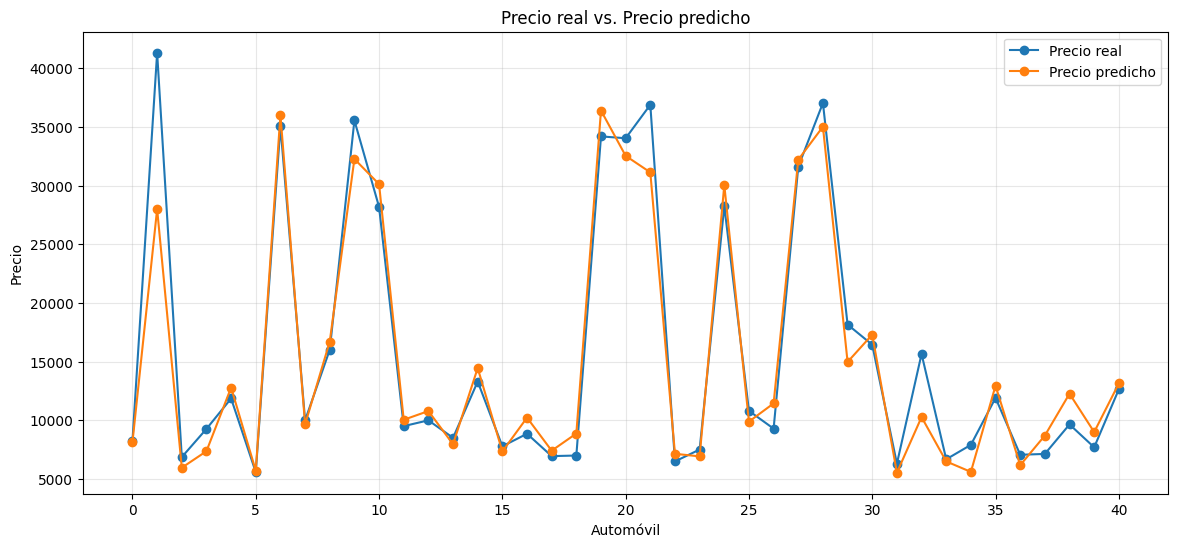

In [23]:
import matplotlib.pyplot as plt

# Reiniciar el índice para que los automóviles aparezcan
# consecutivamente: 0, 1, 2, 3...
resultados_grafica = resultados.reset_index(drop=True)

plt.figure(figsize=(14, 6))

# Precio real
plt.plot(
    resultados_grafica.index,
    resultados_grafica["Precio real"],
    marker="o",
    label="Precio real"
)

# Precio predicho
plt.plot(
    resultados_grafica.index,
    resultados_grafica["Precio predicho"],
    marker="o",
    label="Precio predicho"
)

plt.xlabel("Automóvil")
plt.ylabel("Precio")
plt.title("Precio real vs. Precio predicho")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretación de la gráfica real vs. predicho

Las dos líneas permiten comparar directamente los precios reales con los precios calculados por el modelo.

Cuando ambas líneas se encuentran cerca, la predicción fue similar al precio real. Cuando existe una separación mayor, el error de predicción también es mayor.

La gráfica permite observar de manera sencilla que un buen resultado general no significa que todas las predicciones tengan el mismo nivel de precisión.


## Paso 11. Registro del experimento en MLflow

Se registrará el modelo base de Regresión Lineal junto con
los parámetros utilizados y las métricas obtenidas durante
la evaluación.

### Configuración de MLflow

Se establece la conexión con la base de datos central utilizada por MLflow para almacenar los experimentos del proyecto.

Esto permite que los parámetros y métricas registrados desde el notebook puedan consultarse posteriormente desde la interfaz de MLflow.

In [24]:
import os
import mlflow

tracking_db = os.path.abspath(
    "../mlflow_tracking/mlflow.db"
)

mlflow.set_tracking_uri(
    f"sqlite:///{tracking_db}"
)

print("Tracking URI:")
print(mlflow.get_tracking_uri())

/Users/fgomezrubio/.pyenv/versions/3.11.9/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tracking URI:
sqlite:////Users/fgomezrubio/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Operaciones ML/mlflow_tracking/mlflow.db


### Creación del experimento

Se establece el experimento `Automobile - Regresion Lineal`.

Si el experimento todavía no existe, MLflow lo crea. Si ya existe, simplemente lo selecciona para registrar nuevas ejecuciones.

Un mismo experimento puede contener diferentes ejecuciones o `runs`, lo que permite conservar el historial y comparar resultados.

In [25]:
mlflow.set_experiment(
    "Automobile - Regresion Lineal"
)

<Experiment: artifact_location=('/Users/fgomezrubio/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Operaciones '
 'ML/Tercera Semana/mlruns/3'), creation_time=1791091420496, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1791151570811, lifecycle_stage='active', name='Automobile - Regresion Lineal', tags={}, trace_location=None, workspace='default'>

### Registro de la ejecución

Se registra una nueva ejecución del modelo dentro del experimento.

MLflow almacena los principales parámetros utilizados durante el entrenamiento y las métricas obtenidas durante la evaluación.

Cada vez que se vuelva a ejecutar esta sección se generará un nuevo `run`. Esto permite conservar el historial y comparar diferentes ejecuciones del modelo.

In [26]:
with mlflow.start_run(
    run_name="Regresion_Lineal_Baseline"
) as run:

    mlflow.log_param("modelo", "LinearRegression")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("random_state", 42)
    mlflow.log_param(
        "imputacion_numerica",
        "median"
    )
    mlflow.log_param(
        "imputacion_categorica",
        "most_frequent"
    )
    mlflow.log_param(
        "encoding",
        "OneHotEncoder"
    )

    mlflow.log_metric("MAE", float(mae))
    mlflow.log_metric("RMSE", float(rmse))
    mlflow.log_metric("R2", float(r2))
    mlflow.log_metric("MAPE", float(mape))

    print("Experimento registrado correctamente.")
    print("Run ID:", run.info.run_id)

Experimento registrado correctamente.
Run ID: 46d4b41bda8f463888a4d60791f701f4


### Reflexión

El desarrollo de este ejercicio permitió comprender de manera práctica la importancia de establecer un **baseline** antes de realizar ajustes o probar modelos más complejos. El baseline funciona como un punto de referencia que permite determinar si los cambios posteriores realmente representan una mejora. En este caso, se utilizó un modelo de **Regresión Lineal** como primera aproximación para predecir el precio de los automóviles a partir de las variables disponibles.

Los resultados obtenidos muestran un **R² aproximado de 0.94**, lo que indica que el modelo logra explicar una proporción considerable de la variabilidad observada en los precios. Sin embargo, métricas como **MAE y MAPE** permiten complementar esta interpretación, ya que muestran el error desde una perspectiva más cercana al valor de las predicciones. Por ejemplo, el MAPE cercano al 11.46 % permite dimensionar el error promedio en términos porcentuales.

El uso de **MLflow** permitió registrar estos resultados como una ejecución del experimento, conservando métricas, parámetros y demás información asociada al modelo. Esto facilita comparar posteriormente el baseline contra nuevas ejecuciones, por ejemplo, después de modificar variables, realizar transformaciones o utilizar otro algoritmo.

Por lo tanto, el objetivo no consiste únicamente en obtener un modelo con buenos resultados, sino en contar con un **punto de partida medible y reproducible**. A partir de este baseline será posible determinar objetivamente si los siguientes cambios mejoran el desempeño del modelo o si, por el contrario, no aportan un beneficio significativo.

Esta versión tiene alrededor de **210 palabras**, así que ya supera cómodamente el mínimo de 150.

## Evidencia del experimento en MLflow

La siguiente captura muestra el experimento registrado en MLflow,
incluyendo las ejecuciones realizadas y las métricas obtenidas.

![Evidencia MLflow](MLflow_capturas_consolidadas.png)
